# Heave comparison — IMU vs GPS

Side-by-side comparison of three heave (vertical displacement) estimates over the
same `t = 800-3200 s` ocean-drift window, plus a raw-position sanity check:

1. **GPS RTK hMSL** — direct vertical displacement, band-passed (ground truth; agrees with CDIP).
2. **IMU accel ÷(2πf)⁴** — tilt-corrected vertical accel PSD divided by `(2πf)⁴` (the
   method in `PendulumFFT_Simple.ipynb` heave cell).
3. **IMU band-passed `z_bp`** — tilt-corrected vertical accel double-integrated in the
   time domain with the band-pass re-applied after each integration.

The two IMU routes share the *same* `a_v`; only the accel→displacement step differs.

Assumes the IMU (`imuLog00082.csv`) and UBX (`dataLog00081.ubx`) logs were started
together, so a common `t_s = 0` aligns them.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.signal import welch, butter, filtfilt
from scipy.integrate import cumulative_trapezoid
from pyubx2 import UBXReader

g = 9.81  # m/s²

## 1 — Configuration

In [2]:
IMU_CSV  = '/Users/Alexander/Repositories/Ocean_MAE_223/Ocean_Test_Success/imuLog00082.csv'
UBX_FILE = '/Users/Alexander/Repositories/Ocean_MAE_223/Ocean_Test_Success/dataLog00081.ubx'

SEG_START, SEG_END = 800, 3200      # analysis window (s from log start)
F_LO, F_HI         = 0.04, 0.50     # ocean-wave band (Hz)
NPERSEG_IMU        = 8192           # Welch segment (IMU, ~10 Hz)
NPERSEG_GPS        = 2048           # Welch segment (GPS, ~5 Hz)

## 2 — Load IMU
Same preprocessing as `PendulumFFT_Simple.ipynb`: drop pre-sync (year-2000) rows,
build the time axis, convert accelerations from milli-g to m/s².

In [3]:
df = pd.read_csv(IMU_CSV)
df['time'] = pd.to_datetime(df['Timestamp'], format='%Y/%m/%d %H:%M:%S.%f')
df = df[df['time'].dt.year >= 2001].reset_index(drop=True)
df['t_s'] = (df['time'] - df['time'].iloc[0]).dt.total_seconds()
for c in ['AccX', 'AccY', 'AccZ']:
    df[c] = df[c] / 1000 * g
fs_imu = 1.0 / np.median(np.diff(df['t_s'].values))
print(f'IMU: {len(df)} rows, fs = {fs_imu:.2f} Hz, duration {df.t_s.iloc[-1]:.0f} s')

IMU: 49464 rows, fs = 10.00 Hz, duration 5057 s


## 3 — Load GPS (UBX)
Same NAV-PVT + NAV-HPPOSLLH merge as `DATA/plot_ubx_track.ipynb`.

In [4]:
def parse_ubx(path):
    pvt, hppos = {}, {}
    with open(path, 'rb') as f:
        for _, parsed in UBXReader(f):
            if not hasattr(parsed, 'identity'):
                continue
            iTOW = getattr(parsed, 'iTOW', None)
            if iTOW is None:
                continue
            if parsed.identity == 'NAV-PVT':
                pvt[iTOW] = dict(
                    iTOW=iTOW,
                    year=getattr(parsed, 'year', 0), month=getattr(parsed, 'month', 0),
                    day=getattr(parsed, 'day', 0), hour=getattr(parsed, 'hour', 0),
                    minute=getattr(parsed, 'min', 0), second=getattr(parsed, 'sec', 0),
                    fix_type=getattr(parsed, 'fixType', 0),
                    carrier_solution=getattr(parsed, 'carrSoln', 0),
                    lat_pvt=float(getattr(parsed, 'lat', 0.0)),
                    lon_pvt=float(getattr(parsed, 'lon', 0.0)),
                    hmsl_pvt=getattr(parsed, 'hMSL', 0) / 1000.0,
                    v_acc_pvt=getattr(parsed, 'vAcc', 0) / 1000.0,
                )
            elif parsed.identity == 'NAV-HPPOSLLH':
                lat = float(getattr(parsed, 'lat', 0.0)); lon = float(getattr(parsed, 'lon', 0.0))
                hpLat = float(getattr(parsed, 'latHp', getattr(parsed, 'hpLat', 0.0)))
                hpLon = float(getattr(parsed, 'lonHp', getattr(parsed, 'hpLon', 0.0)))
                hmsl = getattr(parsed, 'hMSL', 0)
                hpHMSL = getattr(parsed, 'hMSLHp', getattr(parsed, 'hpHMSL', 0))
                hppos[iTOW] = dict(
                    lat_hp=lat + hpLat, lon_hp=lon + hpLon,
                    hmsl_hp=(hmsl + hpHMSL * 0.1) / 1000.0,
                    v_acc_hp=getattr(parsed, 'vAcc', 0) / 10000.0,
                )
    use_hp = len(hppos) > 0
    print(f'NAV-PVT: {len(pvt)}  NAV-HPPOSLLH: {len(hppos)}  -> using {"HP" if use_hp else "PVT"}')
    rows = []
    for iTOW in sorted(pvt):
        p = pvt[iTOW].copy(); hp = hppos.get(iTOW, {})
        if hp:
            p['latitude'], p['longitude'] = hp['lat_hp'], hp['lon_hp']
            p['hmsl'], p['v_acc'] = hp['hmsl_hp'], hp['v_acc_hp']
        else:
            p['latitude'], p['longitude'] = p['lat_pvt'], p['lon_pvt']
            p['hmsl'], p['v_acc'] = p['hmsl_pvt'], p['v_acc_pvt']
        rows.append(p)
    g = pd.DataFrame(rows)
    g['t_s'] = (g['iTOW'] - g['iTOW'].iloc[0]) / 1000.0
    return g

gps = parse_ubx(UBX_FILE)
fs_gps = 1.0 / np.median(np.diff(gps['t_s'].values))
print(f'GPS: {len(gps)} epochs, fs = {fs_gps:.2f} Hz, duration {gps.t_s.iloc[-1]:.0f} s')

Serial stream terminated unexpectedly. 38 bytes requested, 22 bytes returned.


NAV-PVT: 24343  NAV-HPPOSLLH: 24814  -> using HP
GPS: 24343 epochs, fs = 5.00 Hz, duration 5062 s


## 4 — IMU vertical acceleration + band-passed displacement
Tilt-correct (low-pass gravity direction, project, subtract |g|) to get `a_v`, then
build `z_bp` by double-integrating with the band-pass re-applied after each step.

In [5]:
t_imu = df['t_s'].values
A = df[['AccX', 'AccY', 'AccZ']].values

# tilt correction -> vertical (heave) acceleration, gravity removed
b_lp, a_lp = butter(2, F_LO / (fs_imu / 2), 'low')
G = filtfilt(b_lp, a_lp, A, axis=0)
gmag = np.linalg.norm(G, axis=1)
a_v = np.einsum('ij,ij->i', A, G / gmag[:, None]) - gmag

# band-passed time-domain displacement (re-band-pass after each integration)
b_bp, a_bp = butter(4, [F_LO / (fs_imu / 2), F_HI / (fs_imu / 2)], 'band')
a_bpf = filtfilt(b_bp, a_bp, a_v)
v_bp = filtfilt(b_bp, a_bp, cumulative_trapezoid(a_bpf, t_imu, initial=0.0))
z_bp = filtfilt(b_bp, a_bp, cumulative_trapezoid(v_bp,  t_imu, initial=0.0))
print('a_v and z_bp computed over full record')

a_v and z_bp computed over full record


## 5 — Three heave spectra over the 800-3200 s window

In [6]:
def moments(fw, Sd):
    m0 = np.trapezoid(Sd, fw)
    m1 = np.trapezoid(fw * Sd, fw)
    m2 = np.trapezoid(fw**2 * Sd, fw)
    return dict(Hs=4.0 * np.sqrt(m0), Tp=1.0 / fw[np.argmax(Sd)],
                Tm01=m0 / m1, Tm02=np.sqrt(m0 / m2))

# ---- IMU segment mask ----
mseg = (t_imu >= SEG_START) & (t_imu <= SEG_END)
nseg = int(mseg.sum())

# (2) IMU accel ÷(2πf)^4
a_wave = filtfilt(b_bp, a_bp, a_v[mseg])
f1, Pacc = welch(a_wave, fs=fs_imu, nperseg=min(NPERSEG_IMU, nseg))
w1 = (f1 >= F_LO) & (f1 <= F_HI)
f_imu4, Sd_imu4 = f1[w1], Pacc[w1] / ((2 * np.pi * f1[w1]) ** 4)

# (3) IMU band-passed z_bp (already displacement)
f2, Pz = welch(z_bp[mseg], fs=fs_imu, nperseg=min(NPERSEG_IMU, nseg))
w2 = (f2 >= F_LO) & (f2 <= F_HI)
f_zbp, Sd_zbp = f2[w2], Pz[w2]

# (1) GPS RTK hMSL -> displacement PSD directly
mg = ((gps['carrier_solution'] == 2) & (gps['fix_type'] == 3) &
      (gps['v_acc'] <= 0.05) & (gps['t_s'] >= SEG_START) & (gps['t_s'] <= SEG_END))
d = gps.loc[mg].reset_index(drop=True)
tg, h = d['t_s'].values, d['hmsl'].values
tu = np.arange(tg[0], tg[-1], 1.0 / fs_gps)
hu = np.interp(tu, tg, h)                       # uniform grid (RTK dropouts)
bg, ag = butter(4, [F_LO / (fs_gps / 2), F_HI / (fs_gps / 2)], 'band')
hw = filtfilt(bg, ag, hu)
f3, Pg = welch(hw, fs=fs_gps, nperseg=min(NPERSEG_GPS, len(hw)))
w3 = (f3 >= F_LO) & (f3 <= F_HI)
f_gps, Sd_gps = f3[w3], Pg[w3]

P = {'GPS RTK hMSL': moments(f_gps, Sd_gps),
     'IMU accel ÷(2πf)^4': moments(f_imu4, Sd_imu4),
     'IMU z_bp (time-domain)': moments(f_zbp, Sd_zbp)}
print(f'{"source":24s} {"Hs (m)":>8s} {"Tp (s)":>8s} {"Tm01 (s)":>9s} {"Tm02 (s)":>9s}')
for k, v in P.items():
    print(f'{k:24s} {v["Hs"]:8.2f} {v["Tp"]:8.1f} {v["Tm01"]:9.1f} {v["Tm02"]:9.1f}')

source                     Hs (m)   Tp (s)  Tm01 (s)  Tm02 (s)
GPS RTK hMSL                 0.94      6.9       6.5       6.0
IMU accel ÷(2πf)^4           1.20     18.6       8.1       7.0
IMU z_bp (time-domain)       1.20     18.6       7.8       6.9


## 6 — Spectra side by side
Left: linear PSD (true energy weighting). Right: semilog-y (reveals the low-frequency
behaviour, where `÷(2πf)⁴` amplifies accelerometer noise).

/var/folders/44/drcq5kgn0vjf1mzfb_9lj2d80000gn/T/ipykernel_32614/3905266277.py:22: RuntimeWarning: divide by zero encountered in divide
  secax = ax.secondary_xaxis('top', functions=(lambda x: 1.0 / x, lambda T: 1.0 / T))


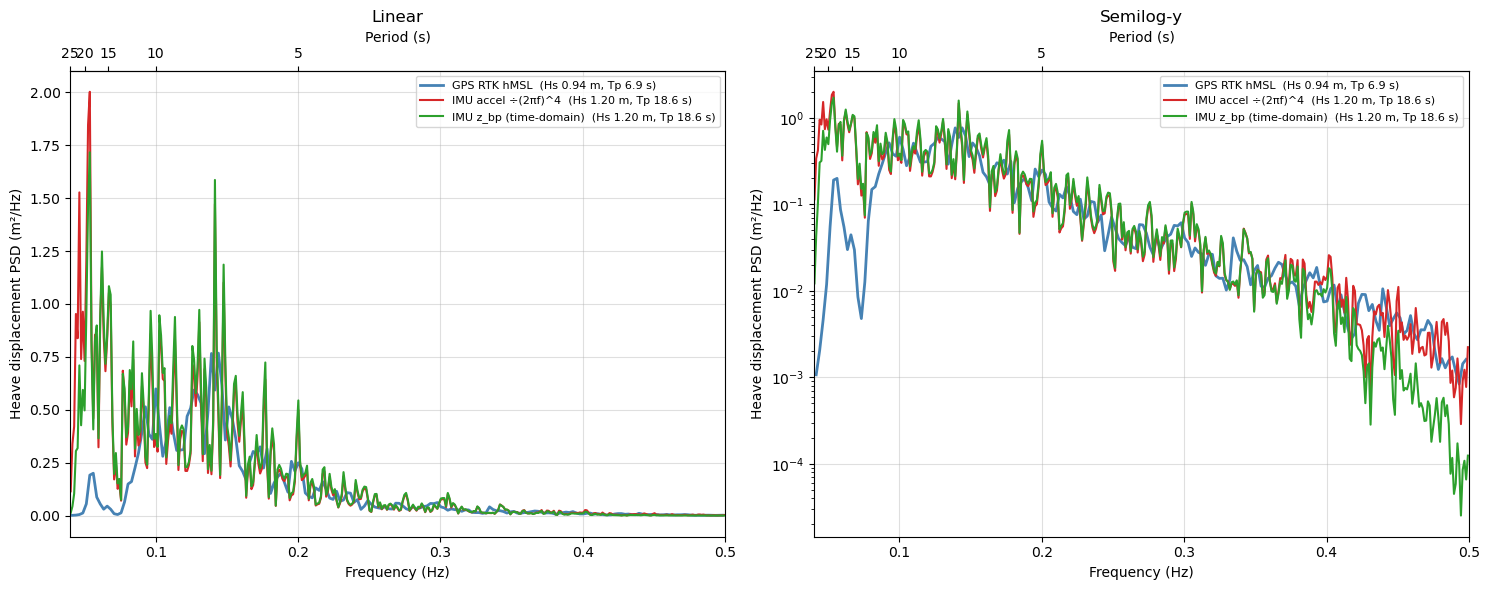

In [7]:
series = [
    ('GPS RTK hMSL',           f_gps,  Sd_gps,  'steelblue', 2.0),
    ('IMU accel ÷(2πf)^4',     f_imu4, Sd_imu4, 'C3',        1.5),
    ('IMU z_bp (time-domain)', f_zbp,  Sd_zbp,  'C2',        1.5),
]

fig, axes = plt.subplots(1, 2, figsize=(15, 6))
for ax, logy in zip(axes, [False, True]):
    for label, f, Sd, c, lw in series:
        hs = P[label]['Hs']; tp = P[label]['Tp']
        ax.plot(f, Sd, color=c, lw=lw, label=f'{label}  (Hs {hs:.2f} m, Tp {tp:.1f} s)')
    ax.set_xlim(F_LO, F_HI)
    ax.set_xlabel('Frequency (Hz)')
    ax.set_ylabel('Heave displacement PSD (m²/Hz)')
    ax.grid(True, alpha=0.4)
    ax.legend(fontsize=8)
    if logy:
        ax.set_yscale('log')
        ax.set_title('Semilog-y')
    else:
        ax.set_title('Linear')
    secax = ax.secondary_xaxis('top', functions=(lambda x: 1.0 / x, lambda T: 1.0 / T))
    secax.set_xlabel('Period (s)')
plt.tight_layout()
plt.show()

## 7 — Raw position comparison
The "raw" IMU position is a naive double-integration of acceleration (mean removed,
no tilt correction, no band-pass) over the same window — the same thing the GPS
measures directly. GPS is shown in a local ENU frame relative to the segment start.

Note the IMU body axes (X/Y/Z) are **not** aligned with ENU and the integration
drifts quadratically, so the y-scales differ by orders of magnitude (separate axes).
This panel is the "why we can't just integrate" illustration.

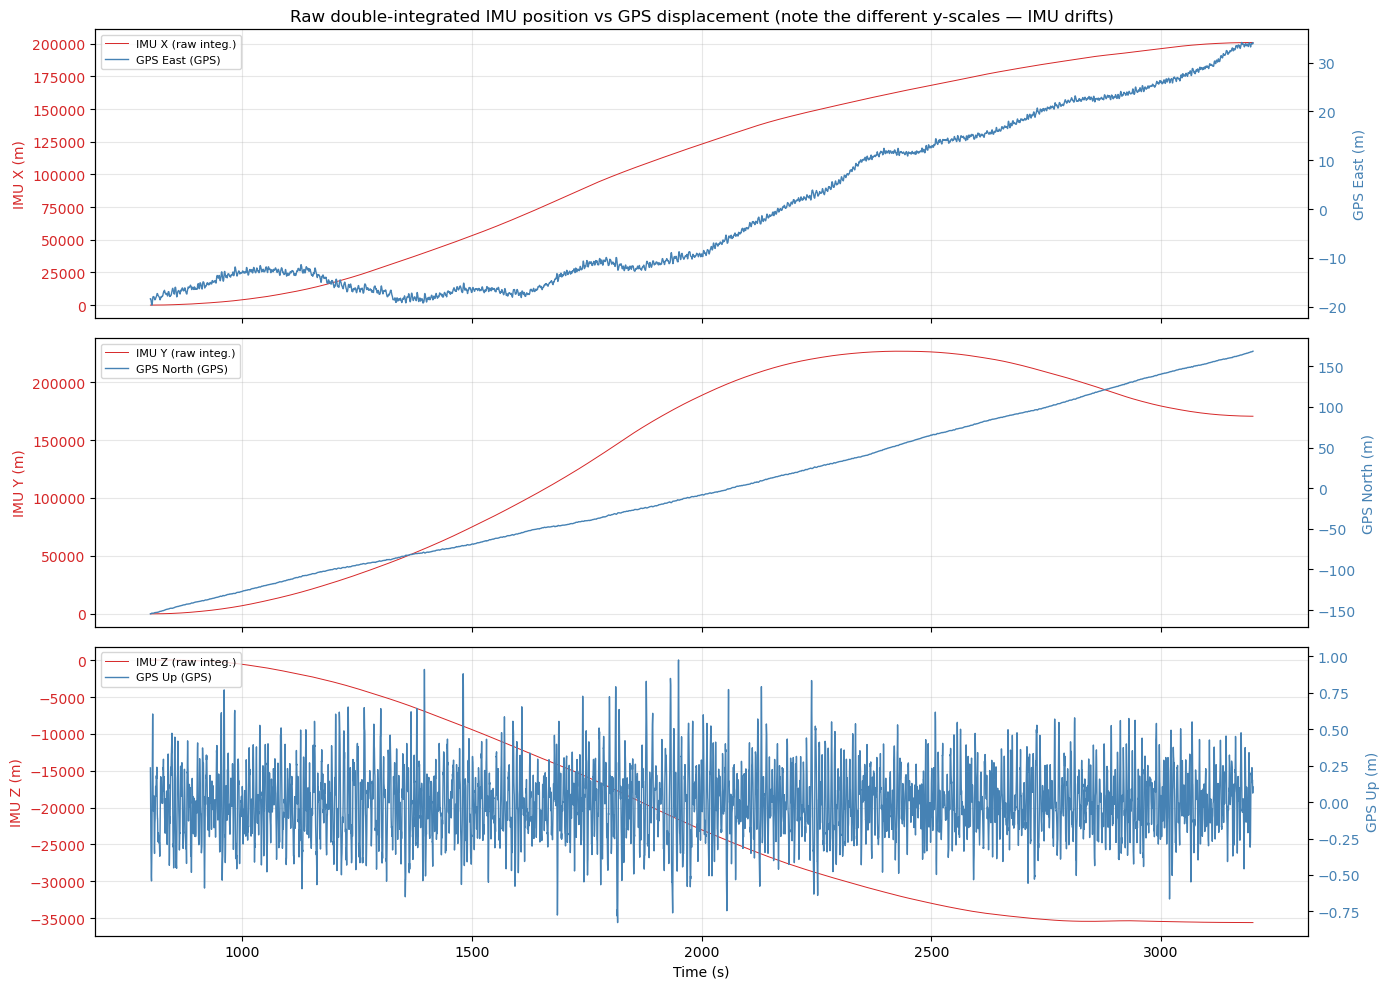

IMU raw drift over segment  X 201008 m  Y 170539 m  Z -35596 m
GPS displacement range      E 53.8 m  N 323.2 m  U 180 cm


In [8]:
# --- raw IMU double integration over the segment ---
t_seg = t_imu[mseg]
acc_seg = A[mseg] - A[mseg].mean(axis=0)            # remove gravity/bias DC
vel = cumulative_trapezoid(acc_seg, t_seg, axis=0, initial=0.0)
pos = cumulative_trapezoid(vel,     t_seg, axis=0, initial=0.0)   # m (drifts)

# --- GPS ENU over the segment (3D fixes) ---
mgp = (gps['fix_type'] == 3) & (gps['t_s'] >= SEG_START) & (gps['t_s'] <= SEG_END)
dp = gps.loc[mgp].reset_index(drop=True)
R = 6_378_137.0
lat0, lon0, alt0 = dp['latitude'].mean(), dp['longitude'].mean(), dp['hmsl'].mean()
east  = np.radians(dp['longitude'] - lon0) * R * np.cos(np.radians(lat0))
north = np.radians(dp['latitude']  - lat0) * R
up    = dp['hmsl'] - alt0
tg2 = dp['t_s'].values

imu_axes = [('IMU X', pos[:, 0]), ('IMU Y', pos[:, 1]), ('IMU Z', pos[:, 2])]
gps_axes = [('GPS East', east), ('GPS North', north), ('GPS Up', up)]

fig, axes = plt.subplots(3, 1, figsize=(14, 10), sharex=True)
for ax, (il, iv), (gl, gv) in zip(axes, imu_axes, gps_axes):
    l1, = ax.plot(t_seg, iv, color='C3', lw=0.7, label=f'{il} (raw integ.)')
    ax.set_ylabel(f'{il} (m)', color='C3')
    ax.tick_params(axis='y', labelcolor='C3')
    axr = ax.twinx()
    l2, = axr.plot(tg2, gv, color='steelblue', lw=1.0, label=f'{gl} (GPS)')
    axr.set_ylabel(f'{gl} (m)', color='steelblue')
    axr.tick_params(axis='y', labelcolor='steelblue')
    ax.grid(True, alpha=0.3)
    ax.legend(handles=[l1, l2], fontsize=8, loc='upper left')
axes[0].set_title('Raw double-integrated IMU position vs GPS displacement '
                  '(note the different y-scales — IMU drifts)')
axes[-1].set_xlabel('Time (s)')
plt.tight_layout()
plt.show()

print(f'IMU raw drift over segment  X {pos[-1,0]:.0f} m  Y {pos[-1,1]:.0f} m  Z {pos[-1,2]:.0f} m')
print(f'GPS displacement range      E {east.max()-east.min():.1f} m  '
      f'N {north.max()-north.min():.1f} m  U {(up.max()-up.min())*100:.0f} cm')

## 8 — `F_LO` sweep
Sweep only the band-pass **lower edge** (keeping the tilt-corrected `a_v` fixed) to
test whether the spurious ~18.6 s IMU peak is low-frequency contamination in `a_v`
rather than real wave energy. The GPS curve stays fixed as ground truth. If the IMU
`Tp` walks toward the GPS ~7 s and `Hs` drops toward 0.94 m as `F_LO` rises, the peak
is contamination — and the fix is a better (gyro-fused) tilt estimate, not just a
higher cutoff.

F_LO (Hz)   Hs (m)   Tp (s)  Tm01 (s)  Tm02 (s)
  GPS ref     0.94      6.9       6.5       6.0
     0.04     1.20     18.6       8.1       7.0
     0.06     1.03      7.1       6.8       6.2
     0.08     0.94      7.1       6.2       5.7
     0.10     0.85      7.1       5.7       5.3
     0.12     0.75      7.1       5.2       5.0


/var/folders/44/drcq5kgn0vjf1mzfb_9lj2d80000gn/T/ipykernel_32614/1714442399.py:42: RuntimeWarning: divide by zero encountered in divide
  secax = ax.secondary_xaxis('top', functions=(lambda x: 1.0 / x, lambda T: 1.0 / T))


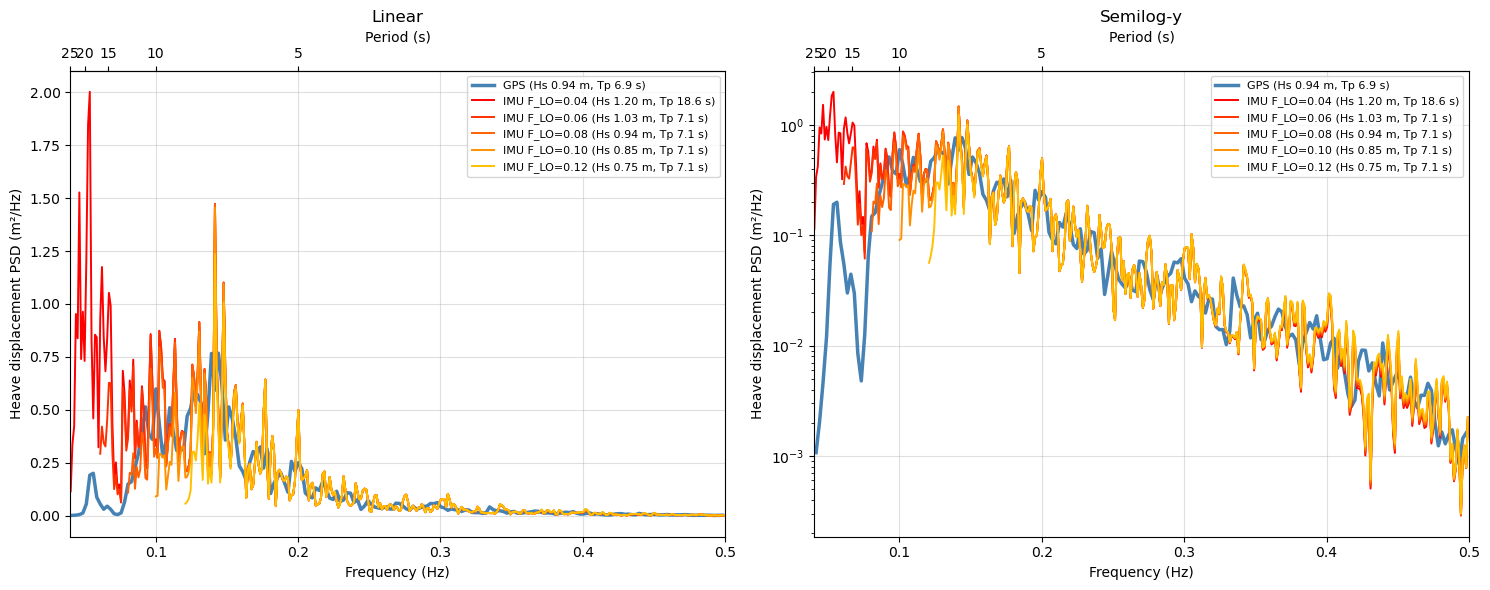

In [9]:
# ── F_LO sweep: does raising the band's lower edge fix the spurious IMU peak? ──
# Keep the SAME tilt-corrected a_v (its gravity low-pass is fixed), and sweep only
# the band-pass LOWER edge. This isolates the band-edge / low-frequency-leakage
# effect from the tilt correction. For each F_LO we band-pass a_v to [F_LO, F_HI],
# take the accel PSD, and convert to displacement via ÷(2πf)^4. The GPS curve is
# fixed (it's the ground truth). If the IMU peak walks from ~18.6 s toward the
# GPS ~7 s and Hs drops toward 0.94 m as F_LO rises, the spurious peak is
# low-frequency contamination in a_v, not real wave energy.
F_LO_SWEEP = [0.04, 0.06, 0.08, 0.10, 0.12]

sweep = []
for flo in F_LO_SWEEP:
    b, a = butter(4, [flo / (fs_imu / 2), F_HI / (fs_imu / 2)], 'band')
    aw = filtfilt(b, a, a_v[mseg])
    fS, Pa = welch(aw, fs=fs_imu, nperseg=min(NPERSEG_IMU, nseg))
    wS = (fS >= flo) & (fS <= F_HI)
    fw, Sd = fS[wS], Pa[wS] / ((2 * np.pi * fS[wS]) ** 4)
    sweep.append((flo, fw, Sd, moments(fw, Sd)))

gp = P['GPS RTK hMSL']
print(f'{"F_LO (Hz)":>9s} {"Hs (m)":>8s} {"Tp (s)":>8s} {"Tm01 (s)":>9s} {"Tm02 (s)":>9s}')
print(f'{"GPS ref":>9s} {gp["Hs"]:8.2f} {gp["Tp"]:8.1f} {gp["Tm01"]:9.1f} {gp["Tm02"]:9.1f}')
for flo, _, _, m in sweep:
    print(f'{flo:9.2f} {m["Hs"]:8.2f} {m["Tp"]:8.1f} {m["Tm01"]:9.1f} {m["Tm02"]:9.1f}')

colors = plt.cm.autumn(np.linspace(0, 0.75, len(F_LO_SWEEP)))
fig, axes = plt.subplots(1, 2, figsize=(15, 6))
for ax, logy in zip(axes, [False, True]):
    ax.plot(f_gps, Sd_gps, color='steelblue', lw=2.5,
            label=f'GPS (Hs {gp["Hs"]:.2f} m, Tp {gp["Tp"]:.1f} s)')
    for (flo, fw, Sd, m), c in zip(sweep, colors):
        ax.plot(fw, Sd, color=c, lw=1.4,
                label=f'IMU F_LO={flo:.2f} (Hs {m["Hs"]:.2f} m, Tp {m["Tp"]:.1f} s)')
    ax.set_xlim(F_LO_SWEEP[0], F_HI)
    ax.set_xlabel('Frequency (Hz)')
    ax.set_ylabel('Heave displacement PSD (m²/Hz)')
    ax.grid(True, alpha=0.4)
    ax.legend(fontsize=8)
    ax.set_title('Semilog-y' if logy else 'Linear')
    if logy:
        ax.set_yscale('log')
    secax = ax.secondary_xaxis('top', functions=(lambda x: 1.0 / x, lambda T: 1.0 / T))
    secax.set_xlabel('Period (s)')
plt.tight_layout()
plt.show()


## 9 — Gyro-fused tilt (complementary filter)
The `F_LO` sweep showed the spurious peak is wave-band tilt leaking gravity into
`a_v`. Rather than brute-force high-passing it away (which also cuts real swell),
estimate the gravity direction with a **complementary filter**: integrate the
**gyro** for the wave-band tilt and anchor slow drift to the **accelerometer**
direction. If this kills the 0.04–0.06 Hz lump, the IMU should match GPS while
keeping `F_LO = 0.04`.

Mean tilt  low-pass 16.3°   gyro-fused 18.3°
Tilt std   low-pass 22.32°   gyro-fused 21.81°  (gyro-fused tracks wave-band tilt the low-pass smears)

source                         Hs (m)   Tp (s)  Tm01 (s)  Tm02 (s)
GPS RTK hMSL                     0.94      6.9       6.5       6.0
IMU low-pass tilt (F_LO .04)     1.20     18.6       8.1       7.0
IMU gyro-fused  (F_LO .04)       1.11     18.6       7.9       6.9


/var/folders/44/drcq5kgn0vjf1mzfb_9lj2d80000gn/T/ipykernel_32614/3486838657.py:71: RuntimeWarning: divide by zero encountered in divide
  secax = ax.secondary_xaxis('top', functions=(lambda x: 1.0 / x, lambda T: 1.0 / T))


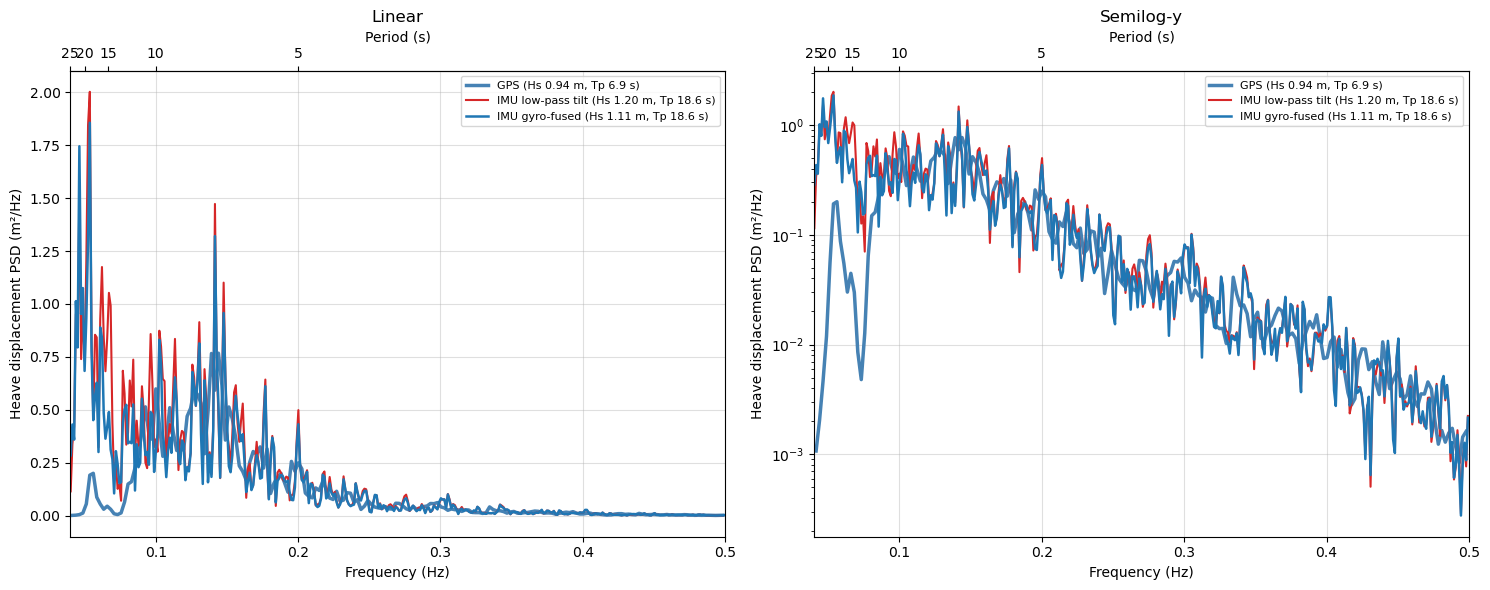

In [10]:
# ── Gyro-fused tilt: complementary filter on the gravity direction ──
# The low-pass tilt estimate smears wave-band tilt, leaking gravity into a_v at
# 0.04-0.06 Hz. A complementary filter tracks the gravity direction in the body
# frame using the GYRO at high frequency (so it follows the actual wave-band
# tilt) and corrects slow gyro drift with the ACCELEROMETER direction at low
# frequency. Vertical accel = (specific force · gravity-direction) - |g|, so the
# wave-correlated gravity leakage is removed at the source — letting us keep
# F_LO = 0.04 and still recover real long-period swell.
#
# ALPHA sets the accel-correction weight per sample; the complementary crossover
# is ~ ALPHA * fs / (2π).  ALPHA=0.02 @ 10 Hz → ~0.03 Hz, i.e. the accel only
# fixes drift slower than the wave band; gyro owns the wave band.
ALPHA = 0.02

GYR = np.radians(df[['GyrX', 'GyrY', 'GyrZ']].values)      # rad/s
dt  = np.diff(t_imu, prepend=t_imu[0] - 1.0 / fs_imu)      # per-sample dt (s)
acc_hat = A / np.linalg.norm(A, axis=1, keepdims=True)     # measured up-direction

ghat = np.empty_like(A)
g_est = acc_hat[0].copy()                                  # init from first accel
for i in range(len(A)):
    # predict: gravity direction in body frame rotates by -ω × ĝ
    g_pred = g_est - np.cross(GYR[i], g_est) * dt[i]
    g_pred /= np.linalg.norm(g_pred)
    # correct toward the accelerometer direction (low-frequency anchor)
    g_est = (1.0 - ALPHA) * g_pred + ALPHA * acc_hat[i]
    g_est /= np.linalg.norm(g_est)
    ghat[i] = g_est

# vertical (heave) acceleration with gyro-fused gravity removed
gmag_lp   = filtfilt(b_lp, a_lp, np.linalg.norm(A, axis=1))
a_v_fused = np.einsum('ij,ij->i', A, ghat) - gmag_lp

# how much do the two tilt estimates disagree, and where (tilt-angle PSD)?
tilt_lp    = np.degrees(np.arccos(np.clip((G / gmag[:, None])[:, 2], -1, 1)))
tilt_fused = np.degrees(np.arccos(np.clip(ghat[:, 2], -1, 1)))
print(f'Mean tilt  low-pass {tilt_lp.mean():.1f}°   gyro-fused {tilt_fused.mean():.1f}°')
print(f'Tilt std   low-pass {tilt_lp.std():.2f}°   gyro-fused {tilt_fused.std():.2f}°  '
      f'(gyro-fused tracks wave-band tilt the low-pass smears)')

# heave spectrum from the fused a_v, SAME F_LO = 0.04 as the original
a_wave_f = filtfilt(b_bp, a_bp, a_v_fused[mseg])
ff, Paf = welch(a_wave_f, fs=fs_imu, nperseg=min(NPERSEG_IMU, nseg))
wf = (ff >= F_LO) & (ff <= F_HI)
f_fused, Sd_fused = ff[wf], Paf[wf] / ((2 * np.pi * ff[wf]) ** 4)
mf = moments(f_fused, Sd_fused)

print()
print(f'{"source":28s} {"Hs (m)":>8s} {"Tp (s)":>8s} {"Tm01 (s)":>9s} {"Tm02 (s)":>9s}')
print(f'{"GPS RTK hMSL":28s} {gp["Hs"]:8.2f} {gp["Tp"]:8.1f} {gp["Tm01"]:9.1f} {gp["Tm02"]:9.1f}')
pl = P['IMU accel ÷(2πf)^4']
print(f'{"IMU low-pass tilt (F_LO .04)":28s} {pl["Hs"]:8.2f} {pl["Tp"]:8.1f} {pl["Tm01"]:9.1f} {pl["Tm02"]:9.1f}')
print(f'{"IMU gyro-fused  (F_LO .04)":28s} {mf["Hs"]:8.2f} {mf["Tp"]:8.1f} {mf["Tm01"]:9.1f} {mf["Tm02"]:9.1f}')

fig, axes = plt.subplots(1, 2, figsize=(15, 6))
for ax, logy in zip(axes, [False, True]):
    ax.plot(f_gps,   Sd_gps,   color='steelblue', lw=2.5,
            label=f'GPS (Hs {gp["Hs"]:.2f} m, Tp {gp["Tp"]:.1f} s)')
    ax.plot(f_imu4,  Sd_imu4,  color='C3', lw=1.5,
            label=f'IMU low-pass tilt (Hs {pl["Hs"]:.2f} m, Tp {pl["Tp"]:.1f} s)')
    ax.plot(f_fused, Sd_fused, color='C0', lw=1.8,
            label=f'IMU gyro-fused (Hs {mf["Hs"]:.2f} m, Tp {mf["Tp"]:.1f} s)')
    ax.set_xlim(F_LO, F_HI)
    ax.set_xlabel('Frequency (Hz)')
    ax.set_ylabel('Heave displacement PSD (m²/Hz)')
    ax.grid(True, alpha=0.4)
    ax.legend(fontsize=8)
    ax.set_title('Semilog-y' if logy else 'Linear')
    if logy:
        ax.set_yscale('log')
    secax = ax.secondary_xaxis('top', functions=(lambda x: 1.0 / x, lambda T: 1.0 / T))
    secax.set_xlabel('Period (s)')
plt.tight_layout()
plt.show()


## 10 — Final IMU heave spectrum (`F_LO = 0.08 Hz`)
The pragmatic estimate: start the band at the sweep's sweet spot (0.08 Hz) so the
low-frequency platform-swing contamination is excluded, keeping the same `a_v` and
`÷(2πf)⁴` conversion. GPS overlaid as ground truth.

IMU heave spectrum at F_LO = 0.08 Hz
  Hs   = 0.94 m   (GPS 0.94 m)
  Tp   = 7.1 s    (GPS 6.9 s)
  Tm01 = 6.2 s    (GPS 6.5 s)
  Tm02 = 5.7 s    (GPS 6.0 s)


/var/folders/44/drcq5kgn0vjf1mzfb_9lj2d80000gn/T/ipykernel_32614/3458349687.py:34: RuntimeWarning: divide by zero encountered in divide
  secax = ax.secondary_xaxis('top', functions=(lambda x: 1.0 / x, lambda T: 1.0 / T))


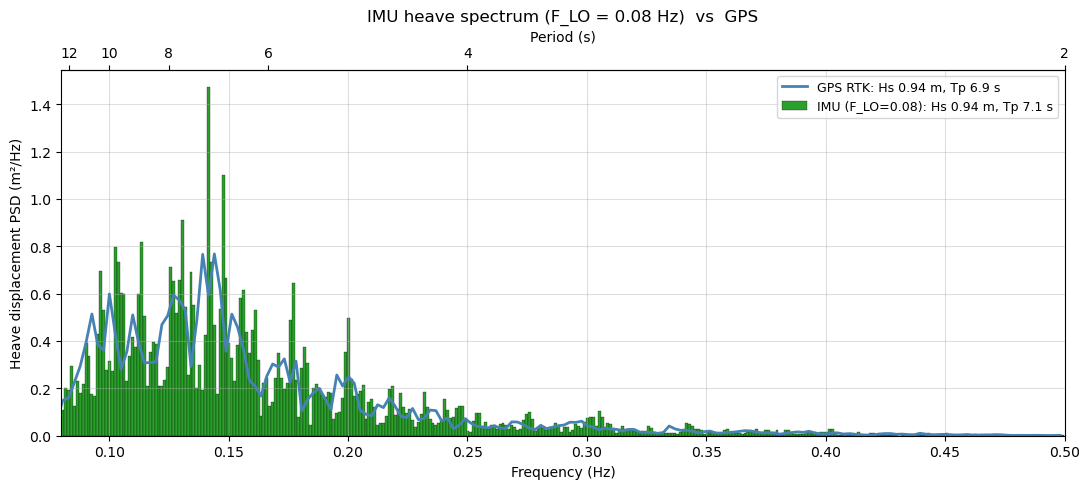

In [11]:
# ── Final IMU heave spectrum at the F_LO = 0.08 Hz sweet spot ──
# The pragmatic estimate from the sweep: high-pass the low-frequency platform-swing
# contamination out by starting the band at 0.08 Hz, keeping the same tilt-corrected
# a_v and ÷(2πf)^4 conversion. Bars span one Welch bin (matching the heave-spectrum
# cells in the other notebooks); the GPS curve is overlaid as ground truth.
F_LO_FINAL = 0.08

b8, a8 = butter(4, [F_LO_FINAL / (fs_imu / 2), F_HI / (fs_imu / 2)], 'band')
a_wave8 = filtfilt(b8, a8, a_v[mseg])
f8, Pa8 = welch(a_wave8, fs=fs_imu, nperseg=min(NPERSEG_IMU, nseg))
w8 = (f8 >= F_LO_FINAL) & (f8 <= F_HI)
fw8, Sd8 = f8[w8], Pa8[w8] / ((2 * np.pi * f8[w8]) ** 4)
m8 = moments(fw8, Sd8)
df_bin = f8[1] - f8[0]

print(f'IMU heave spectrum at F_LO = {F_LO_FINAL} Hz')
print(f'  Hs   = {m8["Hs"]:.2f} m   (GPS {gp["Hs"]:.2f} m)')
print(f'  Tp   = {m8["Tp"]:.1f} s    (GPS {gp["Tp"]:.1f} s)')
print(f'  Tm01 = {m8["Tm01"]:.1f} s    (GPS {gp["Tm01"]:.1f} s)')
print(f'  Tm02 = {m8["Tm02"]:.1f} s    (GPS {gp["Tm02"]:.1f} s)')

fig, ax = plt.subplots(figsize=(11, 5))
ax.bar(fw8, Sd8, width=df_bin, align='center',
       color='C2', edgecolor='black', linewidth=0.2,
       label=f'IMU (F_LO={F_LO_FINAL}): Hs {m8["Hs"]:.2f} m, Tp {m8["Tp"]:.1f} s')
ax.plot(f_gps, Sd_gps, color='steelblue', lw=2.0,
        label=f'GPS RTK: Hs {gp["Hs"]:.2f} m, Tp {gp["Tp"]:.1f} s')
ax.set_xlabel('Frequency (Hz)')
ax.set_ylabel('Heave displacement PSD (m²/Hz)')
ax.set_title(f'IMU heave spectrum (F_LO = {F_LO_FINAL} Hz)  vs  GPS')
ax.set_xlim(F_LO_FINAL, F_HI)
ax.grid(True, alpha=0.4)
ax.legend(fontsize=9)
secax = ax.secondary_xaxis('top', functions=(lambda x: 1.0 / x, lambda T: 1.0 / T))
secax.set_xlabel('Period (s)')
plt.tight_layout()
plt.show()
